In [1]:
import argparse
import copy
import time

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.nn.functional import softmax
from torch.utils.data import DataLoader, Dataset, TensorDataset, Subset
from torchvision import datasets, transforms

from sklearn import preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, MinMaxScaler

import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

# Utils

In [2]:
import torch
import torch.nn.functional as F
import numpy as np
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc


###################
# MODEL PERFORMANCES
###################

def stable_softmax(logits):
    # Numerically stable softmax
    predictions = torch.exp(logits - torch.max(logits, dim=-1, keepdims=True).values)
    predictions = predictions / torch.sum(predictions, dim=-1, keepdims=True)
    return predictions

def predict_labels(model, dl, device="cpu"):
    model.eval()
    y_pred, y_true = [], []

    with torch.no_grad():
        for imgs, lbls in dl:
            imgs, lbls = imgs.to(device), lbls.to(device)

            logits = model(imgs)
            predictions = logits.argmax(dim=1)

            y_pred.append(predictions.cpu())
            y_true.append(lbls.cpu())
    
    return torch.cat(y_true), torch.cat(y_pred)

def predict_proba(model, dl, device="cpu", use_stable_softmax=False, return_labels = False):
    model.eval()
    probs, labels = [], []

    with torch.no_grad():
        for imgs, lbls in dl:
            imgs, lbls = imgs.to(device), lbls.to(device)

            logits = model(imgs)
            if use_stable_softmax:
                p = stable_softmax(logits)
                probs.extend(p)
            else:
                probs.extend(F.softmax(logits, dim=1))

            if return_labels:
                labels.extend(lbls)
    
    if return_labels:
        return torch.stack(probs), torch.stack(labels)
    else:
        return torch.stack(probs)

def compute_logits(model, dl, device="cpu", return_labels = False):
    model.eval()
    logits, labels = [], []

    with torch.no_grad():
        for imgs, lbls in dl:
            imgs, lbls = imgs.to(device), lbls.to(device)

            logits.extend(model(imgs))
            if return_labels:
                labels.extend(lbls)
    
    if return_labels:
        return torch.stack(logits), torch.stack(labels)
    else:
        return torch.stack(logits)

def predict_phi_scores(model, ds, device="cpu", return_labels=False):
    probs, labels = predict_proba(model, ds, device=device, use_stable_softmax=True, return_labels=True)
    probs, labels = probs.cpu().numpy(), labels.cpu().numpy()
    
    # Compute probability of the true class and the probability of all other classes
    # np.arange(predictions.shape[0]) is needed to correctly indexing of numpy array
    p_true = probs[np.arange(probs.shape[0]), labels]
    probs[np.arange(probs.shape[0]), labels] = 0
    p_wrong = np.sum(probs, axis=-1)

    # Compute phi
    eps = 1e-45
    phis = np.log(p_true + eps) - np.log(p_wrong + eps)
    
    if return_labels:
        return phis, labels
    else:
        return phis

def predict_losses(model, ds, device="cpu", return_labels=False):
    logits, labels = compute_logits(model, ds, device=device, return_labels=True)  
    losses = F.cross_entropy(logits, labels, reduction="none")

    losses, labels = losses.cpu().numpy(), labels.cpu().numpy()

    if return_labels:
        return losses, labels
    else:
        return losses

def get_labels(dl):
    labels = []
    for _, lbls in dl:
        labels.extend(lbls)
    
    return torch.tensor(labels)

def compute_accuracy(model, dl, device="cpu"):
    y_true, y_pred = predict_labels(model, dl, device=device)
    return accuracy_score(y_true=y_true, y_pred=y_pred)

def compute_error_rate(model, dl, device="cpu"):
    return 1 - compute_accuracy(model, dl, device=device)



###################
# SAVE AND LOAD UTILS
###################

def save_model(model, name, verbose=True, device="cpu"):
    if device=="cuda":
        torch.save(model.state_dict(), f"{name}.pth")
        if verbose:
            print(f"Model params saved in '{name}.pth'")
    
    model = model.to("cpu")
    torch.save(model.state_dict(), f"{name}_cpu.pth")
    if verbose:
        print(f"Model params saved in '{name}_cpu.pth'")
    
    model.to(device)

def load_model(model, name, verbose=True, device="cpu"):
    if device=="cpu":
        path = f"{name}_cpu.pth"
    else:
        path = f"{name}.pth"
    model.load_state_dict(torch.load(path))
    if verbose:
        print(f"Model loaded from '{path}'")

def save_array(arr, name, verbose=True):
    np.save(f"{name}.npy", arr)
    if verbose:
        print(f"Array saved in '{name}.npy'")

def load_array(name, verbose=True):
    arr = np.load(f"{name}.npy")
    if verbose:
        print(f"Array loaded from '{name}.npy'")
    return arr



###################
# PLOT UTILS
###################

def roc_chart(true_memberships, scores, axis: plt.Axes, color="darkorange", title="", log_scale=False):

    fpr, tpr, roc = roc_curve(true_memberships, scores)

    axis.plot(fpr, tpr, color=color, lw=1, label='ROC curve (area = %0.2f)' % auc(fpr, tpr))
    axis.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
    if log_scale:
        axis.set_xlim([1e-5, 1.0])
        axis.set_ylim([1e-5, 1.0])
        axis.set_xscale("log")
        axis.set_yscale("log")
    else:
        axis.set_xlim([0, 1.0])
        axis.set_ylim([0, 1.0])
    axis.set_xlabel('False Positive Rate')
    axis.set_ylabel('True Positive Rate')
    if title!= "":
        axis.set_title(title)
    else:
        axis.set_title('ROC')
    axis.legend(loc="lower right")



###################
# MODEL ACTIVATION UTILS
###################

def get_activation(name, dict):
    def hook(model, input, output):
        dict[name] = output.detach()
    return hook

def get_activations(model, img):
    handles = []
    activations = {}

    for name, layer in model.named_modules():
        if name != "":
            handles.append(layer.register_forward_hook(get_activation(name, activations)))
    
    model(img)

    for handle in handles:
        handle.remove() 

    return activations





def get_ith_data_of_label(ds, lbl, i):
    dl = DataLoader(ds, batch_size=1)

    for batch in dl:
        if batch[1][0]==lbl:
            if i>0:
                i-=1
                continue
            else:
                return batch[0]


# FL

In [3]:
import copy
from torch.utils.data import ConcatDataset, DataLoader
import numpy as np
import torch.nn as nn
import torch
import torch.optim as optim
from typing import Any

###################
# CLASSES
###################

class Client:
    def __init__(self, id, ds, model, dl = None, data_idxs = None):
        self.id = id
        self.ds = ds
        self.dl = dl
        self.data_idxs = data_idxs
        self.model = model

class RoundLog:
    def __init__(self, round_, global_model, client_updates: dict[int, Any]):
        self.round = round_
        self.global_model = global_model
        self.client_updates = client_updates
    
    def get_partecipating_client_ids(self):
        return self.client_updates.keys()

###################
# FEDAVG
###################

def fedavg_from_state_dict(global_model, client_dicts, client_weights):
    global_model = copy.deepcopy(global_model)

    avg = {}
    total_weights = sum(client_weights)
    for key in client_dicts[0].keys():
        avg[key] = sum([client_weights[i]*cd[key] for i, cd in enumerate(client_dicts)]) / total_weights

    global_model.load_state_dict(avg)
    return global_model

def fedavg_with_weights(clients, client_weights):
    client_dicts = [c.model.state_dict() for c in clients]
    return fedavg_from_state_dict(clients[0].model, client_dicts, client_weights)

def fedavg_from_models(client_models, client_weights):
    client_dicts = [model.state_dict() for model in client_models]
    return fedavg_from_state_dict(client_models[0], client_dicts, client_weights)

def fedavg_data_based_weights(clients):
    client_dicts = [c.model.state_dict() for c in clients]
    client_weights = [len(c.ds) for c in clients]
    return fedavg_from_state_dict(clients[0].model, client_dicts, client_weights)

def fedavg(clients):
    client_dicts = [c.model.state_dict() for c in clients]
    client_weights = [1 for _ in clients]
    return fedavg_from_state_dict(clients[0].model, client_dicts, client_weights)

def train_client(train_fn, global_model, client, epochs, device="cpu", inplace=False):
    client_model = copy.deepcopy(global_model)
    client_model.load_state_dict(global_model.state_dict())

    client_model = client_model.to(device)
    train_fn(client_model, client.dl, epochs, device=device)
    client_model = client_model.to("cpu")

    if inplace:
        client.model = client_model

    return client_model


def train_fedavg(init_global_model, clients, rounds, epochs, train_fn, device="cpu", return_log=False, verbose=False, eval_dl = None):

    global_model = init_global_model
    global_model = global_model.to("cpu")

    if verbose:
        train_ds = ConcatDataset([c.ds for c in clients])
        train_dl = DataLoader(train_ds, batch_size=256)

    if return_log:
        logs = []
        logs.append(RoundLog(0, global_model.state_dict(), {}))
    
    for r in range(1, rounds+1):
        client_updates = {}
        for client in clients:
            client_model = train_client(train_fn, global_model, client, epochs, device=device, inplace=False)
            client_updates[client.id] = client_model.state_dict()
            client.model = client_model

        global_model = fedavg(clients)
        logs.append(RoundLog(1, global_model.state_dict(), client_updates))

        if verbose:
            global_model = global_model.to(device)
            train_acc = compute_accuracy(global_model, train_dl, device=device)

            eval_acc = -1
            if eval_dl != None:
                eval_acc = compute_accuracy(global_model, eval_dl, device=device)
            
            global_model = global_model.to("cpu")
            
            print(f"Ended training for round {r}/{rounds}, train acc = {train_acc:.4f}, eval acc = {eval_acc:.4f}")

    global_model = global_model.to(device)

    if return_log:
        return global_model, logs
    else:
        return global_model

def fed_retrain(init_global_model, clients, client_ids_to_unlearn, rounds, epochs, train_fn, device="cpu", return_log=False, verbose=False, eval_dl = None):
    remaining_clients = [c for c in clients if c.id not in client_ids_to_unlearn]
    return train_fedavg(init_global_model, remaining_clients, rounds, epochs, train_fn, device=device, return_log=return_log, verbose=verbose, eval_dl = eval_dl)






# Data reconstruction

In [5]:
def train(model, ds_train, ds_test, epochs, lr, momentum, batch_size):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=momentum)

    train_dl = DataLoader(ds_train, batch_size=batch_size, shuffle=True)
    test_dl = DataLoader(ds_test, batch_size=256)
    # Train
    for epoch in range(epochs):
        model.train()
        for x, y in train_dl:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)

            loss.backward()
            optimizer.step()

        train_acc = compute_accuracy(model, train_dl, device=device)
        test_acc = compute_accuracy(model, test_dl, device=device)
        print(f"Epoch {epoch+1}/{epochs} - Loss: {loss.item():.4f} - train acc: {train_acc:.4f} - test acc: {test_acc:.4f}")

In [ ]:
def compute_tv_loss(x):
    diff_i = (x[:, :, 1:, :] - x[:, :, :-1, :]).abs().sum()
    diff_j = (x[:, :, :, 1:] - x[:, :, :, :-1]).abs().sum()
    return diff_i + diff_j

def data_reconstruction(target_model, target_grads, target_lbls, imgs, lr, max_iters, lambda_l2, lambda_tv, print_step=1000, loss_type="euclidean", use=None):
    if use==None:
        use = np.full(len(target_grads), 1)
    imgs.requires_grad_(True)
    #target_model.eval()
    #optimizer = optim.SGD([img], lr=0.001, momentum=0.9)
    optimizer = torch.optim.Adam([imgs], lr=lr)
    criterion = nn.CrossEntropyLoss()

    for i in range(max_iters):
        optimizer.zero_grad()
        target_model.zero_grad()

        loss = criterion(target_model(imgs), target_lbls)

        grads = torch.autograd.grad(
            loss, target_model.parameters(),
            create_graph=True,
            retain_graph=True
        )

        grad_loss = 0.0
        if loss_type=="euclidean":
            for i, (g, gt) in enumerate(zip(grads, target_grads)):
                if use[i]==1:
                    grad_loss += torch.norm(g - gt) ** 2
            grad_loss = grad_loss/len(target_lbls)
        elif loss_type=="cosine": 
            g = torch.cat([g.view(-1) for i, g in enumerate(grads) if use[i]==1])
            gt = torch.cat([g.view(-1) for i, g in enumerate(target_grads) if use[i]==1])  
            #cos = torch.dot(g, gt) / (g.norm() * gt.norm())
            cos = F.cosine_similarity(g, gt, dim=0)
            grad_loss = 1 - cos
            #losses = []
            #for g, gt in zip(grads, target_grads):
            #    cos = F.cosine_similarity(g.flatten(), gt.flatten(), dim=0)
            #    losses.append(1 - cos)
            #
            #grad_loss = torch.mean(torch.stack(losses))

            

        else:
            raise NotImplementedError()

        l2_loss = lambda_l2 * (imgs ** 2).sum()

        tv_loss = lambda_tv * compute_tv_loss(imgs)

        total_loss = grad_loss + l2_loss + tv_loss

        total_loss.backward()
        optimizer.step()

        if (i+1)%print_step==0:
            print(f"Ended epoch {i+1}/{max_iters}")
    
    return imgs.detach().cpu().numpy()


def data_reconstruction_test(target_model, target_imgs, target_lbls, imgs, lr, max_iters, lambda_l2, lambda_tv, print_step=1000, device="cpu", loss_type="euclidean", custom_labels = None):
    if custom_labels==None:
        custom_labels = target_lbls
    
    target_model.zero_grad()
    target_imgs, target_lbls, imgs, custom_labels = target_imgs.to(device), target_lbls.to(device), imgs.to(device), custom_labels.to(device)

    loss = nn.CrossEntropyLoss()(target_model(target_imgs), target_lbls)

    target_grads = torch.autograd.grad(loss, target_model.parameters(), create_graph=False, retain_graph=False)
    target_grads = [g.detach() for g in target_grads]

    return data_reconstruction(target_model, target_grads, custom_labels, imgs, lr, max_iters, lambda_l2, lambda_tv, print_step, loss_type=loss_type)



In [7]:
def data_reconstruction_on_selected_layers(target_model, target_grads, target_lbls, imgs, lr, max_iters, lambda_l2, lambda_tv, layers, print_step=1000, loss_type="euclidean"):
    imgs.requires_grad_(True)
    target_model.eval()
    #optimizer = optim.SGD([img], lr=0.001, momentum=0.9)
    optimizer = torch.optim.Adam([imgs], lr=lr)
    criterion = nn.CrossEntropyLoss()

    for i in range(max_iters):

        optimizer.zero_grad()
        target_model.zero_grad()

        loss = criterion(target_model(imgs), target_lbls)
        loss.backward(create_graph=True)

        grad_loss = 0.0
        if loss_type=="euclidean":
            for layer, gt in zip(layers, target_grads):
                grad_loss += torch.norm(layer.weight.grad - gt) ** 2
        elif loss_type=="cosine": 
            g = []
            gt = []
            for layer, g_real in zip(layers, target_grads):
                g.append(layer.weight.grad)
                gt.append(g_real)
            g = torch.cat([g.view(-1) for g in g])
            gt = torch.cat([g.view(-1) for g in gt])
            
            grad_loss = 1- F.cosine_similarity(g, gt, dim=0, eps=1e-8)

        else:
            raise NotImplementedError()

        l2_loss = lambda_l2 * (imgs ** 2).sum()

        tv_loss = lambda_tv * compute_tv_loss(imgs)

        total_loss = grad_loss + l2_loss + tv_loss

        total_loss.backward()
        optimizer.step()

        if (i+1)%print_step==0:
            print(f"Ended epoch {i+1}/{max_iters}")
    
    return imgs.detach().cpu().numpy()


def data_reconstruction_test_on_selected_layers(target_model, target_imgs, target_lbls, imgs, lr, max_iters, lambda_l2, lambda_tv, layers, print_step=1000, device="cpu", loss_type="euclidean", custom_labels = None):
    if custom_labels==None:
        custom_labels = target_lbls
    
    target_model.zero_grad()
    target_imgs, target_lbls, imgs, custom_labels = target_imgs.to(device), target_lbls.to(device), imgs.to(device), custom_labels.to(device)

    loss = nn.CrossEntropyLoss()(target_model(target_imgs), target_lbls)

    #target_grads = torch.autograd.grad(loss, target_model.parameters(), create_graph=False, retain_graph=False)
    #target_grads = [g.detach() for g in target_grads]
    
    loss = nn.CrossEntropyLoss()(target_model(target_imgs), target_model(target_imgs))
    loss.backward()
    target_grads = []
    for layer in layers:
        target_grads.append(layer.weight.grad.clone())

    target_model.zero_grad()

    return data_reconstruction_on_selected_layers(target_model, target_grads, custom_labels, imgs, lr, max_iters, lambda_l2, lambda_tv, layers, print_step, loss_type=loss_type)



In [8]:
def show_img(img, axis):
    img = torch.tensor(img)
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3,1,1)
    std = torch.tensor([0.2023, 0.1994, 0.2010]).view(3,1,1)
    img = img * std + mean
    axis.imshow(img.permute(1, 2, 0))

def show_img_lfw(img, axis):
    img = torch.tensor(img)
    mean = torch.tensor([0.5, 0.5, 0.5]).view(3,1,1)
    std = torch.tensor([0.5, 0.5, 0.5]).view(3,1,1)
    img = img * std + mean
    axis.imshow(img.permute(1, 2, 0))

# Models

In [9]:
import torchvision

# Model
class MLP1(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        return self.net(x)

class MLP2(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 2048),
            nn.ReLU(),
            nn.Linear(2048, 1024),
            nn.ReLU(),
            nn.Linear(1024, 10)
        )

    def forward(self, x):
        return self.net(x)
    
class MLP2_32(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3*32 * 32, 2048),
            nn.ReLU(),
            nn.Linear(2048, 1024),
            nn.ReLU(),
            nn.Linear(1024, 10)
        )

    def forward(self, x):
        return self.net(x)
    
class deep_MLP2_32(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3*32 * 32, 10000),
            nn.ReLU(),
            nn.Linear(10000, 5000),
            nn.ReLU(),
            nn.Linear(5000, 2500),
            nn.ReLU(),
            nn.Linear(2500, 1000),
            nn.ReLU(),
            nn.Linear(1000, 10),
            nn.ReLU(),
        )

    def forward(self, x):
        return self.net(x)

class LeNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_net = nn.Sequential(
            nn.Conv2d(1, 6, kernel_size=5),    # 28x28 -> 24x24
            nn.Tanh(),
            nn.AvgPool2d(2),                   # 24x24 -> 12x12
            nn.Conv2d(6, 16, kernel_size=5),   # 12x12 -> 8x8
            nn.Tanh(),
            nn.AvgPool2d(2),                   # 8x8 -> 4x4
            nn.Conv2d(16, 120, kernel_size=4), # 4x4 -> 1x1
            nn.Tanh()
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(120, 84),
            nn.Tanh(),
            nn.Linear(84, 10)
        )

    def forward(self, x):
        x = self.conv_net(x)
        x = self.fc(x)
        return x

class SimpleCNN_32(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.fc1 = nn.Linear(128*4*4, 256)
        self.fc2 = nn.Linear(256, 10)
        self.pool = nn.MaxPool2d(2,2)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.pool(x)
        x = self.relu(self.conv2(x))
        x = self.pool(x)
        x = self.relu(self.conv3(x))
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

class SimpleCNN_28(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.fc1 = nn.Linear(32*7*7, 128)
        self.fc2 = nn.Linear(128, 10)
        self.pool = nn.MaxPool2d(2,2)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.pool(x)
        x = self.relu(self.conv2(x))
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

class SimpleCNN_28_avg(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.fc1 = nn.Linear(32*7*7, 128)
        self.fc2 = nn.Linear(128, 10)
        self.pool = nn.AvgPool2d(2,2)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.pool(x)
        x = self.relu(self.conv2(x))
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

class SimpleCNN_32NoPooling(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1, stride=2)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1, stride=2)
        self.fc1 = nn.Linear(32*8*8, 128)
        self.fc2 = nn.Linear(128, 10)
        self.pool = nn.MaxPool2d(2,2)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.conv1(x))
        #x = self.pool(x)
        x = self.relu(self.conv2(x))
        #x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.fc1 = nn.Linear(32*7*7, 128)
        self.fc2 = nn.Linear(128, 10)
        self.pool = nn.MaxPool2d(2,2)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.pool(x)
        x = self.relu(self.conv2(x))
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

def get_mobilenetv2():
    model = torchvision.models.mobilenet_v2(weights=None)
    model.features[0][0].stride = (1, 1)   # remove initial downsampling
    model.classifier[1] = nn.Linear(model.last_channel, 10)
    model = model.to(device)
    return model

def get_resnet18_mnist(num_classes=10):
    model = torchvision.models.resnet18(weights=None)

    model.conv1 = nn.Conv2d(in_channels=1, out_channels=64, kernel_size=3,
        stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    model.fc = nn.Linear(model.fc.in_features, num_classes)

    return model

def get_resnet18_32(num_classes=10):
    model = torchvision.models.resnet18(weights=None)

    model.conv1 = nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3,
        stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    model.fc = nn.Linear(model.fc.in_features, num_classes)

    return model

# MNIST

In [9]:
from torchvision.datasets import MNIST
import torchvision.transforms as transforms

DS_SLICE = 1000
IN_CH = 1
IN_W = 28
CLASSES = 10

transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
ds_train = MNIST(root="./data", train=True, download=True, transform=transform)
ds_test = MNIST(root="./data", train=False, download=True, transform=transform)

ds_train = Subset(ds_train, indices=np.arange(DS_SLICE))


100%|██████████| 9.91M/9.91M [00:00<00:00, 60.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.69MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.7MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.41MB/s]


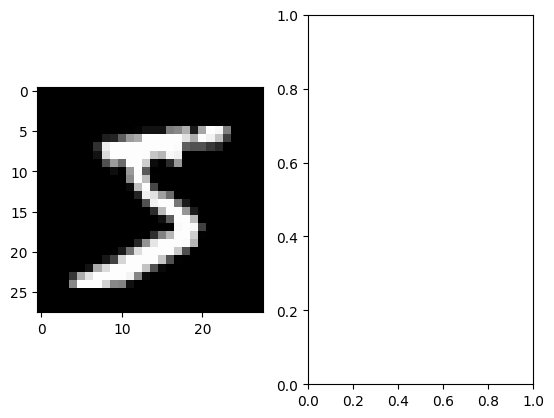

In [10]:
sample_batch_size = 1#64
attack_batch_size = 1#len(ds_train)
sample_dl = DataLoader(ds_train, batch_size=attack_batch_size, shuffle=False)
target_imgs, target_lbls = next(iter(sample_dl))

_, axes = plt.subplots(1, np.max([sample_batch_size, 2]))

for i in range(sample_batch_size):
    axes[i].imshow(target_imgs[i, 0], cmap="gray")

Ended epoch 100/300
Ended epoch 200/300
Ended epoch 300/300


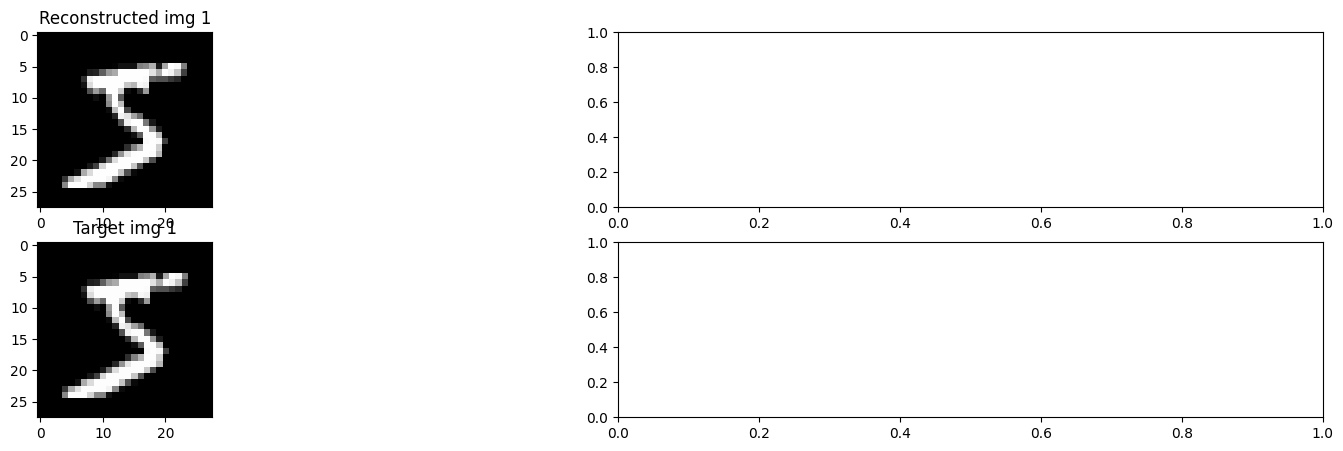

In [11]:
target_model = MLP1().to(device)

MAX_ITERS = 300
PRINT_STEP = 100
LAMBDA_L2 = 0#1e-3
LAMBDA_TV = 0#1e-4
ATT_LR = 0.05


test_dl = DataLoader(ds_test, batch_size=sample_batch_size, shuffle=True)
#init_imgs, _ = copy.deepcopy(next(iter(test_dl)))
init_imgs = torch.randn(attack_batch_size, 1, 28, 28)

imgs = data_reconstruction_test(target_model, target_imgs, target_lbls, init_imgs, ATT_LR, MAX_ITERS, LAMBDA_L2, LAMBDA_TV, device=device, print_step=PRINT_STEP)

samples = np.max([2, sample_batch_size])
fig, axes = plt.subplots(2*int(np.ceil(sample_batch_size/32)), np.min([samples, 32]), figsize=(20, 5))

for i in range(sample_batch_size):
    offset = 2*(i//32)
    idx = i%32
    axes[0+offset, idx].set_title(f"Reconstructed img {i+1}")
    axes[0+offset, idx].imshow(imgs[i, 0], cmap="gray")

    axes[1+offset, idx].set_title(f"Target img {i+1}")
    axes[1+offset, idx].imshow(target_imgs[i, 0], cmap="gray")



Ended epoch 100/300
Ended epoch 200/300
Ended epoch 300/300


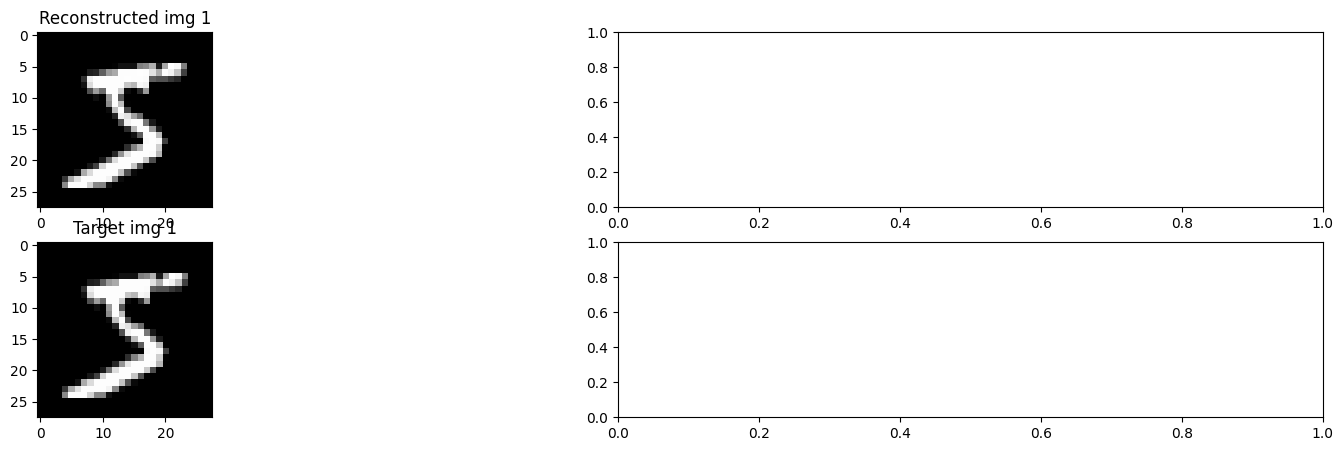

In [12]:
target_model = MLP2().to(device)

MAX_ITERS = 300
PRINT_STEP = 100
LAMBDA_L2 = 0#1e-6
LAMBDA_TV = 0#1e-5
ATT_LR = 0.05



test_dl = DataLoader(ds_test, batch_size=sample_batch_size, shuffle=True)
#init_imgs, _ = copy.deepcopy(next(iter(test_dl)))
#init_imgs = torch.randn(attack_batch_size, 1, 28, 28)
init_imgs = torch.randn(sample_batch_size, 1, 28, 28)
#custom_labels = target_lbls[:sample_batch_size]
#custom_labels = torch.full((sample_batch_size,), 5)
custom_labels = None#torch.randint(0, 10, (sample_batch_size,))

imgs = data_reconstruction_test(target_model, target_imgs, target_lbls, init_imgs, ATT_LR, MAX_ITERS, LAMBDA_L2, LAMBDA_TV, 
                                device=device, print_step=PRINT_STEP, loss_type="euclidean", custom_labels=custom_labels)

samples = np.max([2, sample_batch_size])
fig, axes = plt.subplots(2*int(np.ceil(sample_batch_size/32)), np.min([samples, 32]), figsize=(20, 5))

for i in range(sample_batch_size):
    offset = 2*(i//32)
    idx = i%32
    axes[0+offset, idx].set_title(f"Reconstructed img {i+1}")
    axes[0+offset, idx].imshow(imgs[i, 0], cmap="gray")

    axes[1+offset, idx].set_title(f"Target img {i+1}")
    axes[1+offset, idx].imshow(target_imgs[i, 0], cmap="gray")



Ended epoch 10/100
Ended epoch 20/100
Ended epoch 30/100
Ended epoch 40/100
Ended epoch 50/100
Ended epoch 60/100
Ended epoch 70/100
Ended epoch 80/100
Ended epoch 90/100
Ended epoch 100/100


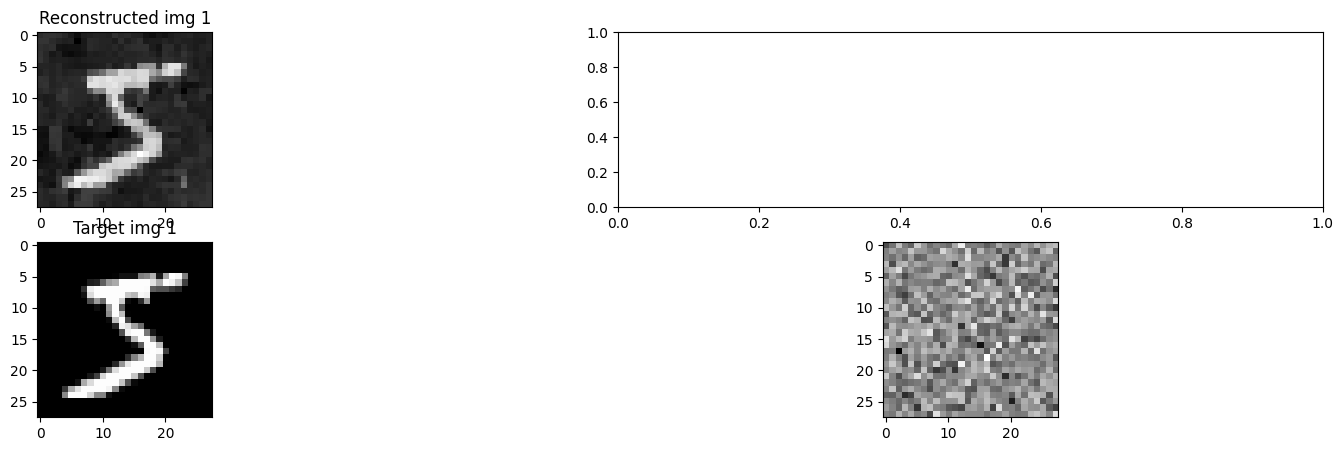

In [13]:
target_model = get_resnet18_mnist().to(device)
target_model.eval()
MAX_ITERS = 100
PRINT_STEP = 10
LAMBDA_L2 = 1e-5
LAMBDA_TV = 1e-5
ATT_LR = 0.3



test_dl = DataLoader(ds_test, batch_size=sample_batch_size, shuffle=False)
skip=2
for img, lbl in test_dl:
    if lbl[0]==5:
        if skip>0:
            skip-=1
            continue
        init_imgs = copy.deepcopy(img)
        break

init_imgs = torch.randn(sample_batch_size, 1, 28, 28)
#init_imgs = target_imgs
#init_imgs = target_imgs + 2*torch.randn(sample_batch_size, 1, 28, 28)
#custom_labels = target_lbls[:sample_batch_size]
#custom_labels = torch.full((sample_batch_size,), 5)
custom_labels = None#torch.randint(0, 10, (sample_batch_size,))

imgs = data_reconstruction_test(target_model, target_imgs, target_lbls, copy.deepcopy(init_imgs), ATT_LR, MAX_ITERS, LAMBDA_L2, LAMBDA_TV, 
                                device=device, print_step=PRINT_STEP, loss_type="cosine", custom_labels=custom_labels)

samples = np.max([2, sample_batch_size])
fig, axes = plt.subplots(2*int(np.ceil(sample_batch_size/32)), np.min([samples, 32]), figsize=(20, 5))

for i in range(sample_batch_size):
    offset = 2*(i//32)
    idx = i%32
    axes[0+offset, idx].set_title(f"Reconstructed img {i+1}")
    axes[0+offset, idx].imshow(imgs[i, 0], cmap="gray")

    axes[1+offset, idx].set_title(f"Target img {i+1}")
    axes[1+offset, idx].imshow(target_imgs[i, 0], cmap="gray")

axes[1, 1].imshow(init_imgs[0, 0], cmap="gray")



Ended epoch 100/300
Ended epoch 200/300
Ended epoch 300/300


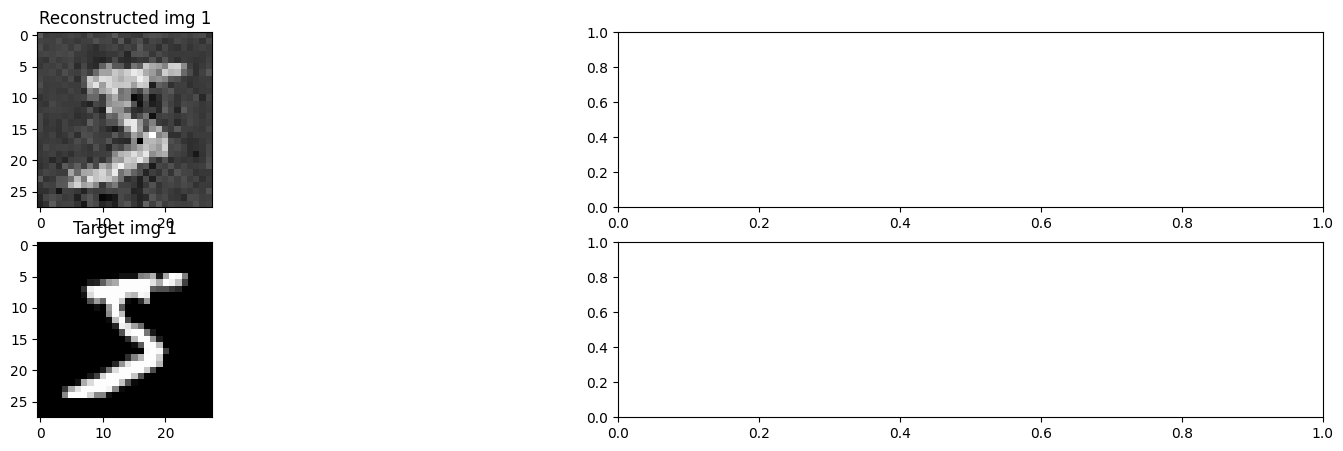

In [14]:
target_model = SimpleCNN().to(device)

MAX_ITERS = 300
PRINT_STEP = 100
LAMBDA_L2 = 0#1e-6
LAMBDA_TV = 0#1e-5
ATT_LR = 0.05



test_dl = DataLoader(ds_test, batch_size=sample_batch_size, shuffle=True)
#init_imgs, _ = copy.deepcopy(next(iter(test_dl)))
#init_imgs = torch.randn(attack_batch_size, 1, 28, 28)
init_imgs = torch.randn(sample_batch_size, 1, 28, 28)
#custom_labels = target_lbls[:sample_batch_size]
#custom_labels = torch.full((sample_batch_size,), 5)
custom_labels = None#torch.randint(0, 10, (sample_batch_size,))

imgs = data_reconstruction_test(target_model, target_imgs, target_lbls, init_imgs, ATT_LR, MAX_ITERS, LAMBDA_L2, LAMBDA_TV, 
                                device=device, print_step=PRINT_STEP, loss_type="euclidean", custom_labels=custom_labels)

samples = np.max([2, sample_batch_size])
fig, axes = plt.subplots(2*int(np.ceil(sample_batch_size/32)), np.min([samples, 32]), figsize=(20, 5))

for i in range(sample_batch_size):
    offset = 2*(i//32)
    idx = i%32
    axes[0+offset, idx].set_title(f"Reconstructed img {i+1}")
    axes[0+offset, idx].imshow(imgs[i, 0], cmap="gray")

    axes[1+offset, idx].set_title(f"Target img {i+1}")
    axes[1+offset, idx].imshow(target_imgs[i, 0], cmap="gray")



# MNIST from fed

In [47]:
from torchvision.datasets import MNIST
import torchvision.transforms as transforms

DS_SLICE = 160
IN_CH = 1
IN_W = 28
CLASSES = 10

N_CLIENTS = 10
BATCH_SIZE = 16
LR = 0.001
MOMENTUM = 0.9
EPOCHS = 5
ROUNDS = 5
CLIENT_IDS_TO_UNLEARN = [0]

def train(model, dl, epochs, device=device):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=LR, momentum=MOMENTUM)

    # Train
    for epoch in range(epochs):
        model.train()
        for x, y in dl:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            loss = criterion(model(x), y)

            loss.backward()
            optimizer.step()


transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
ds_train = MNIST(root="./data", train=True, download=True, transform=transform)
ds_test = MNIST(root="./data", train=False, download=True, transform=transform)

ds_train = Subset(ds_train, indices=np.arange(DS_SLICE))

init_model = MLP2().to(device)

clients = []
client_size = DS_SLICE//N_CLIENTS
for i in range(N_CLIENTS):
    idxs = np.arange(i*client_size, (i+1)*client_size)
    ds = Subset(ds_train, idxs)
    dl = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True)
    clients.append(Client(i, ds, init_model, dl, data_idxs=idxs))


trained_model, train_logs = train_fedavg(copy.deepcopy(init_model), clients, ROUNDS, EPOCHS, train, device=device, return_log=True, verbose=True, eval_dl=DataLoader(Subset(ds_test, np.arange(1000)), batch_size=128))
unlearned_model, unlearning_logs = fed_retrain(copy.deepcopy(init_model), clients, CLIENT_IDS_TO_UNLEARN, ROUNDS, EPOCHS, train, device=device, return_log=True, verbose=True, eval_dl=DataLoader(Subset(ds_test, np.arange(1000)), batch_size=128))


Ended training for round 1/5, train acc = 0.0875, eval acc = 0.0820
Ended training for round 2/5, train acc = 0.1187, eval acc = 0.0970
Ended training for round 3/5, train acc = 0.1812, eval acc = 0.1240
Ended training for round 4/5, train acc = 0.2188, eval acc = 0.1580
Ended training for round 5/5, train acc = 0.2938, eval acc = 0.2090
Ended training for round 1/5, train acc = 0.0833, eval acc = 0.0830
Ended training for round 2/5, train acc = 0.1319, eval acc = 0.0940
Ended training for round 3/5, train acc = 0.1806, eval acc = 0.1120
Ended training for round 4/5, train acc = 0.2014, eval acc = 0.1370
Ended training for round 5/5, train acc = 0.2431, eval acc = 0.1650


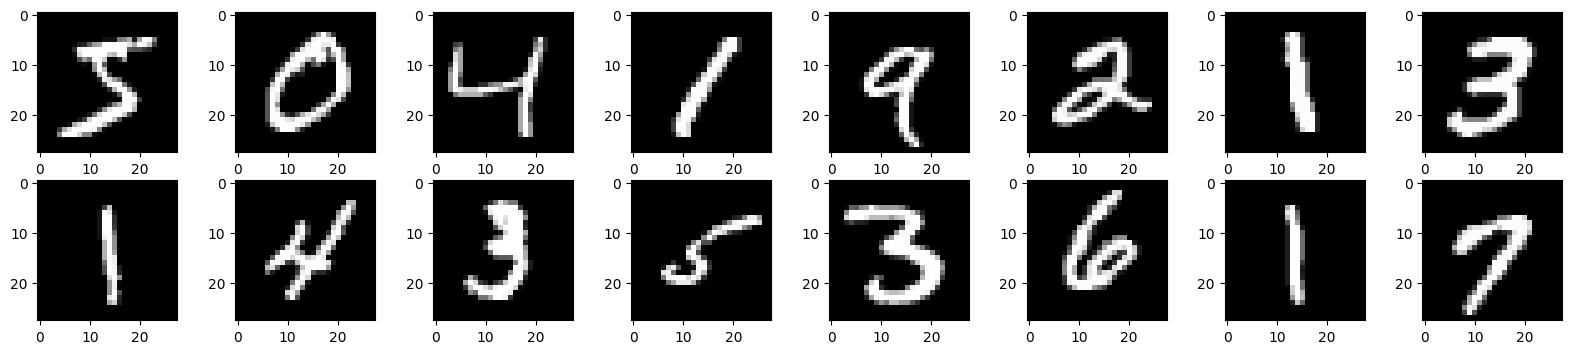

In [48]:
client0_dl = DataLoader(clients[0].ds, batch_size=len(clients[0].ds))
target_imgs, target_lbls = next(iter(client0_dl))

fig, axes = plt.subplots(2, 8, figsize=(20, 4))
axes=axes.flatten()

for i in range(len(target_imgs)):
    axes[i].imshow(target_imgs[i, 0], cmap="gray")

target_imgs, target_lbls = target_imgs.to(device), target_lbls.to(device)

3.39
0.00
8.56
0.02
3.72
0.13


C:\Users\loriz\AppData\Local\Temp\ipykernel_10988\3893290872.py:58: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  reconstructed_imgs = torch.tensor(reconstructed_imgs)


Ended epoch 100/200
Ended epoch 200/200
Ended epoch 100/200
Ended epoch 200/200
Ended epoch 100/200
Ended epoch 200/200
Ended epoch 100/200
Ended epoch 200/200
Ended epoch 100/200
Ended epoch 200/200


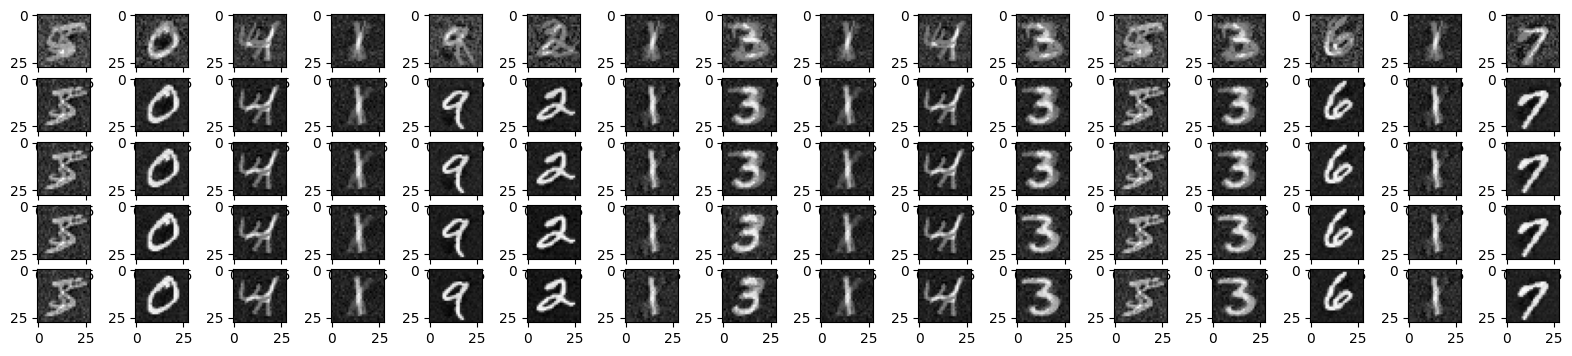

In [68]:
sample_batch_size = len(clients[0].ds)

#test_dl = DataLoader(ds_test, batch_size=len(clients[0].ds), shuffle=True)
#init_imgs, _ = next(iter(test_dl))
#init_imgs = copy.deepcopy(init_imgs)
#init_imgs = torch.randn(len(clients[0].ds), 1, 28, 28)

#init_imgs = torch.randn(sample_batch_size, 1, 28, 28)
init_imgs = []
for lbl in target_lbls:
    init_imgs.append(get_ith_data_of_label(ds_test, lbl, 0))
init_imgs = torch.cat(init_imgs)
#target_lbls = torch.arange(sample_batch_size).to(device)

init_imgs, target_lbls = init_imgs.to(device), target_lbls.to(device)

global_model = type(trained_model)()
client_model = type(trained_model)()
target_model = type(trained_model)()

global_model_sd = train_logs[-2].global_model
client_model_sd = train_logs[-1].client_updates[0]

target_model.load_state_dict(global_model_sd)
target_model = target_model.to(device)
#global_model.load_state_dict(train_logs[-2].global_model)
#client_model.load_state_dict(train_logs[-1].client_updates[0])
#global_model, client_model = global_model.to(device), client_model.to(device)



pseudo_grad = []
for name, gm_val in global_model_sd.items():
    cm_val = client_model_sd[name]
    grad = -(cm_val - gm_val)/(EPOCHS*LR)
    grad = grad.to(device)
    pseudo_grad.append(grad)

loss = nn.CrossEntropyLoss()(trained_model(target_imgs), target_lbls)
real_grad = torch.autograd.grad(loss, trained_model.parameters(), create_graph=False, retain_graph=False)
real_grad = [g.detach() for g in real_grad]

for g, pg in zip(real_grad, pseudo_grad):
    print(f"{(torch.norm(g-pg)**2):.2f}")

MAX_ITERS = 200
PRINT_STEP = 100
LAMBDA_L2 = 0#1e-3
LAMBDA_TV = 0#1e-6
ATT_LR = 0.01

repeat = 5
fig, axes = plt.subplots(repeat, 16, figsize=(20, 4))
#axes=axes.flatten()

reconstructed_imgs = init_imgs
for j in range(repeat):
    reconstructed_imgs = torch.tensor(reconstructed_imgs)
    reconstructed_imgs = data_reconstruction(target_model, pseudo_grad, target_lbls, reconstructed_imgs, ATT_LR, MAX_ITERS, LAMBDA_L2, LAMBDA_TV, print_step=PRINT_STEP, loss_type="cosine")

    for i in range(sample_batch_size):
        axes[j, i].imshow(reconstructed_imgs[i, 0], cmap="gray")

# CIFAR from fed

In [ ]:
from torchvision.datasets import CIFAR10
import torchvision.transforms as transforms

DS_SLICE = 10
CLASSES = 10

N_CLIENTS = 10
BATCH_SIZE = 16
LR = 0.001
MOMENTUM = 1
EPOCHS = 1
ROUNDS = 2
CLIENT_IDS_TO_UNLEARN = [0]

def train(model, dl, epochs, device=device):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=LR, momentum=MOMENTUM)

    # Train
    for epoch in range(epochs):
        model.train()
        for x, y in dl:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            loss = criterion(model(x), y)

            loss.backward()
            optimizer.step()


transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))])
ds_train = CIFAR10(root="./data", train=True, download=True, transform=transform)
ds_test = CIFAR10(root="./data", train=False, download=True, transform=transform)

ds_train = Subset(ds_train, indices=np.arange(DS_SLICE))

init_model = get_resnet18_32(10).to(device)

clients = []
client_size = DS_SLICE//N_CLIENTS
for i in range(N_CLIENTS):
    idxs = np.arange(i*client_size, (i+1)*client_size)
    ds = Subset(ds_train, idxs)
    dl = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True)
    clients.append(Client(i, ds, init_model, dl, data_idxs=idxs))


trained_model, train_logs = train_fedavg(copy.deepcopy(init_model), clients, ROUNDS, EPOCHS, train, device=device, return_log=True, verbose=True, eval_dl=DataLoader(Subset(ds_test, np.arange(1000)), batch_size=128))
#unlearned_model, unlearning_logs = fed_retrain(copy.deepcopy(init_model), clients, CLIENT_IDS_TO_UNLEARN, ROUNDS, EPOCHS, train, device=device, return_log=True, verbose=True, eval_dl=DataLoader(Subset(ds_test, np.arange(1000)), batch_size=128))


Ended training for round 1/2, train acc = 0.2000, eval acc = 0.1090
Ended training for round 2/2, train acc = 0.2000, eval acc = 0.1090


/tmp/ipykernel_101/2829775319.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  img = torch.tensor(img)
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.9802322e-08..1.0].


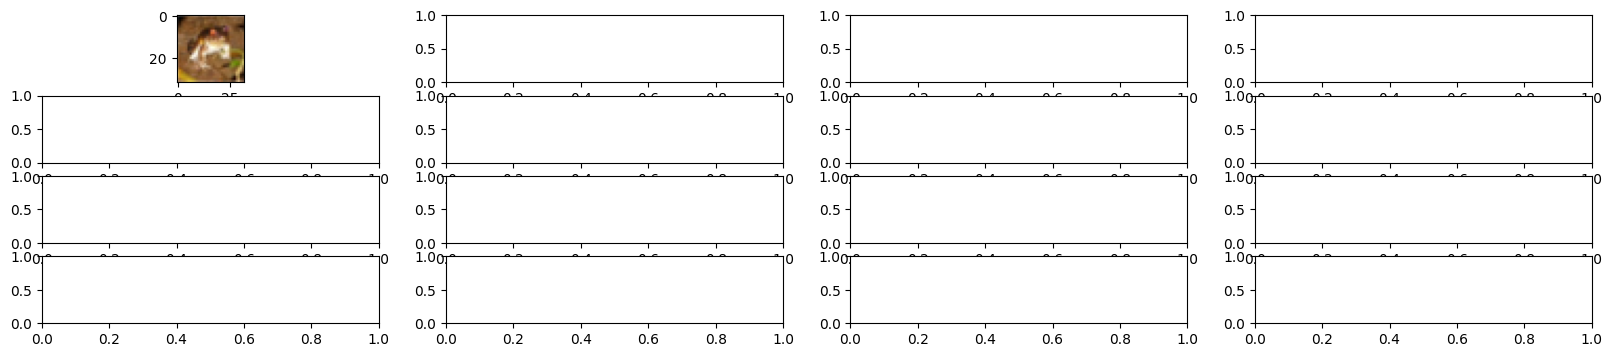

In [24]:
client0_dl = DataLoader(clients[0].ds, batch_size=len(clients[0].ds))
target_imgs, target_lbls = next(iter(client0_dl))

fig, axes = plt.subplots(4, 4, figsize=(20, 4))
axes=axes.flatten()

for i in range(len(target_imgs)):
    show_img(target_imgs[i], axes[i])

target_imgs, target_lbls = target_imgs.to(device), target_lbls.to(device)

In [ ]:
sample_batch_size = len(clients[0].ds)

#test_dl = DataLoader(ds_test, batch_size=len(clients[0].ds), shuffle=True)
#init_imgs, _ = next(iter(test_dl))
#init_imgs = copy.deepcopy(init_imgs)
#init_imgs = torch.randn(len(clients[0].ds), 1, 28, 28)



init_imgs = []
lbl_k = {i: 7 for i in range(10)}
for lbl in target_lbls:
    init_imgs.append(get_ith_data_of_label(ds_test, lbl, lbl_k[lbl.item()]))
    lbl_k[lbl.item()]+=1
init_imgs = torch.cat(init_imgs)

#init_imgs = torch.randn(sample_batch_size, 3, 32, 32)
init_imgs, target_lbls = init_imgs.to(device), target_lbls.to(device)



global_model = get_resnet18_32().to(device)
client_model = get_resnet18_32().to(device)





global_model_sd = train_logs[0].global_model
client_model_sd = train_logs[1].client_updates[0]

global_model.load_state_dict(global_model_sd)
client_model.load_state_dict(client_model_sd)

global_model.zero_grad()

pseudo_grad = []
for i, (cm_param, gm_param) in enumerate(zip(client_model.parameters(), global_model.parameters())):
    if cm_param.requires_grad:
        grad = (gm_param-cm_param)/(EPOCHS*LR)
        pseudo_grad.append(grad.detach())




global_model.train()

loss = nn.CrossEntropyLoss()(global_model(target_imgs), target_lbls)
real_grad = torch.autograd.grad(loss, global_model.parameters(), create_graph=False, retain_graph=False)
real_grad = [g.detach() for g in real_grad]

for g, pg in zip(real_grad, pseudo_grad):
    print(f"{(torch.norm(g-pg)**2):.4f}")








MAX_ITERS = 10000
PRINT_STEP = 500
LAMBDA_L2 = 0#1e-6
LAMBDA_TV = 0#1e-6
ATT_LR = 0.05

global_model = global_model.to(device)
global_model.train()
reconstructed_imgs = data_reconstruction(global_model, pseudo_grad, target_lbls, init_imgs, ATT_LR, 
                                         MAX_ITERS, LAMBDA_L2, LAMBDA_TV, print_step=PRINT_STEP, 
                                         loss_type="euclidean")

loss = nn.CrossEntropyLoss()(global_model(target_imgs), target_lbls)
real_grad = torch.autograd.grad(loss, global_model.parameters(), create_graph=False, retain_graph=False)
real_grad = [g.detach() for g in real_grad]

for g, pg in zip(real_grad, pseudo_grad):
    print(f"{(torch.norm(g-pg)**2):.4f}")

fig, axes = plt.subplots(4, 4, figsize=(20, 20))
axes=axes.flatten()

for i in range(sample_batch_size):
    show_img(reconstructed_imgs[i], axes[i])

'''
repeat = 5
fig, axes = plt.subplots(repeat, np.max([2, sample_batch_size]), figsize=(20, 10))
#axes=axes.flatten()

reconstructed_imgs = init_imgs
for j in range(repeat):
    reconstructed_imgs = torch.tensor(reconstructed_imgs)
    reconstructed_imgs = data_reconstruction(global_model, pseudo_grad, target_lbls, reconstructed_imgs, ATT_LR, MAX_ITERS, LAMBDA_L2, LAMBDA_TV, print_step=PRINT_STEP, loss_type="cosine")

    for i in range(sample_batch_size):
        show_img(reconstructed_imgs[i], axes[j, i])

'''

53.8347
0.3693
0.3556
66.4943
0.1116
0.2073
40.2672
0.1445
0.2199
55.6265
0.2438
0.1376
45.6667
0.1542
0.1787
96.2212
0.1067
0.1230
79.6007
0.2047
0.1273
11.0911
0.1579
0.1273
113.2832
0.2122
0.0909
120.4498
0.1070
0.1218
168.2265
0.1299
0.0900
159.8586
0.2063
0.1196
23.9195
0.1943
0.1196
226.1245
0.2236
0.0627
322.2333
0.3105
0.1145
590.0291
0.3647
0.0713
555.1461
0.2438
0.0892
128.1947
0.6800
0.0892
808.0604
0.5359
0.0762
1081.9006
0.4868
0.0412
2109.7371
0.0729


KeyboardInterrupt: 

In [61]:
print(get_resnet18_32().state_dict().keys())

odict_keys(['conv1.weight', 'bn1.weight', 'bn1.bias', 'bn1.running_mean', 'bn1.running_var', 'bn1.num_batches_tracked', 'layer1.0.conv1.weight', 'layer1.0.bn1.weight', 'layer1.0.bn1.bias', 'layer1.0.bn1.running_mean', 'layer1.0.bn1.running_var', 'layer1.0.bn1.num_batches_tracked', 'layer1.0.conv2.weight', 'layer1.0.bn2.weight', 'layer1.0.bn2.bias', 'layer1.0.bn2.running_mean', 'layer1.0.bn2.running_var', 'layer1.0.bn2.num_batches_tracked', 'layer1.1.conv1.weight', 'layer1.1.bn1.weight', 'layer1.1.bn1.bias', 'layer1.1.bn1.running_mean', 'layer1.1.bn1.running_var', 'layer1.1.bn1.num_batches_tracked', 'layer1.1.conv2.weight', 'layer1.1.bn2.weight', 'layer1.1.bn2.bias', 'layer1.1.bn2.running_mean', 'layer1.1.bn2.running_var', 'layer1.1.bn2.num_batches_tracked', 'layer2.0.conv1.weight', 'layer2.0.bn1.weight', 'layer2.0.bn1.bias', 'layer2.0.bn1.running_mean', 'layer2.0.bn1.running_var', 'layer2.0.bn1.num_batches_tracked', 'layer2.0.conv2.weight', 'layer2.0.bn2.weight', 'layer2.0.bn2.bias', '

In [20]:
print(global_model.state_dict())

OrderedDict({'conv1.weight': tensor([[[[ 0.1734, -0.1781, -0.1028],
          [-0.0397, -0.1483,  0.0864],
          [ 0.1599,  0.1508, -0.0463]],

         [[-0.0085, -0.0988,  0.0691],
          [-0.0761, -0.0804,  0.0471],
          [-0.1597, -0.0583, -0.1858]],

         [[-0.1208, -0.0605, -0.1384],
          [-0.0017, -0.0823, -0.1149],
          [ 0.1572,  0.0788,  0.0995]]],


        [[[-0.1652, -0.0318,  0.0276],
          [-0.0635, -0.0483, -0.1246],
          [-0.1800, -0.1542,  0.1330]],

         [[ 0.0143, -0.0152, -0.1509],
          [-0.0504, -0.1054, -0.0132],
          [ 0.0766, -0.1109,  0.1681]],

         [[ 0.0078, -0.0780,  0.0358],
          [ 0.0905, -0.0018,  0.1232],
          [ 0.1736,  0.1424,  0.1572]]],


        [[[-0.0207, -0.1397,  0.1456],
          [ 0.1783, -0.0996, -0.1055],
          [-0.1606, -0.1542, -0.0596]],

         [[-0.1101,  0.1186,  0.0551],
          [-0.0520,  0.0267,  0.0980],
          [ 0.0182, -0.1241,  0.1187]],

         [[-0.1

# CIFAR

In [9]:
from torchvision.datasets import CIFAR10
import torchvision.transforms as transforms

DS_SLICE = 10000
IN_CH = 3
IN_W = 32
CLASSES = 10

transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))])
ds_train = CIFAR10(root="./data", train=True, download=True, transform=transform)
ds_test = CIFAR10(root="./data", train=False, download=True, transform=transform)

ds_train = Subset(ds_train, indices=np.arange(DS_SLICE))

100%|██████████| 170M/170M [00:03<00:00, 51.3MB/s] 


/tmp/ipykernel_99/2829775319.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  img = torch.tensor(img)
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.9802322e-08..1.0].


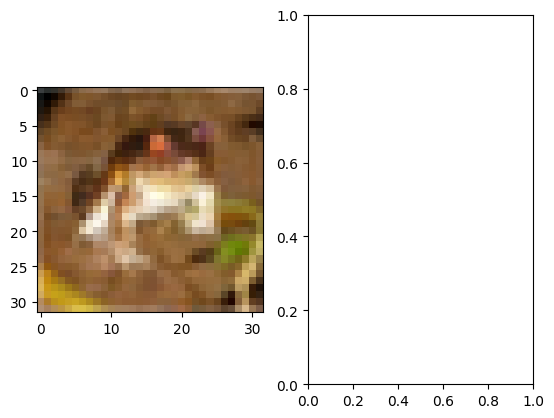

In [11]:
sample_batch_size = 1
attack_batch_size = 1#len(ds_train)
sample_dl = DataLoader(ds_train, batch_size=attack_batch_size, shuffle=False)
target_imgs, target_lbls = next(iter(sample_dl))

_, axes = plt.subplots(1, np.max([2, sample_batch_size]))

for i in range(sample_batch_size):
    show_img(target_imgs[i], axes[i])

Ended epoch 100/300
Ended epoch 200/300


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.4135613..5.803194].
/tmp/ipykernel_99/2829775319.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  img = torch.tensor(img)
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.9802322e-08..1.0].


Ended epoch 300/300


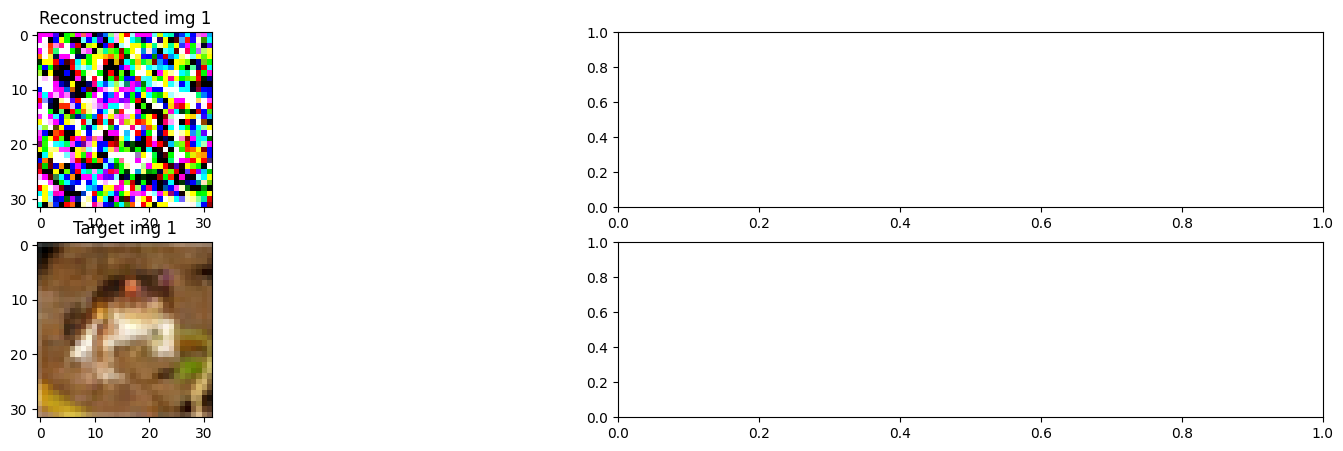

In [46]:
target_model = get_mobilenetv2()

MAX_ITERS = 300
PRINT_STEP = 100
LAMBDA_L2 = 0#1e-3
LAMBDA_TV = 0#1e-4
ATT_LR = 0.1



test_dl = DataLoader(ds_test, batch_size=attack_batch_size, shuffle=True)
#init_imgs, _ = copy.deepcopy(next(iter(test_dl)))
init_imgs = torch.randn(sample_batch_size, 3, 32, 32)


imgs = data_reconstruction_test(target_model, target_imgs, target_lbls, init_imgs, ATT_LR, MAX_ITERS, LAMBDA_L2, LAMBDA_TV, device=device, print_step=PRINT_STEP, loss_type="euclidean")

#fig, axes = plt.subplots(2, sample_batch_size, figsize=(20, 5))
fig, axes = plt.subplots(2, np.max([2, sample_batch_size]), figsize=(20, 5))

for i in range(sample_batch_size):
    axes[0, i].set_title(f"Reconstructed img {i+1}")
    show_img(imgs[i], axes[0, i])

    axes[1, i].set_title(f"Target img {i+1}")
    show_img(target_imgs[i], axes[1, i])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.9802322e-08..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.3100558..1.2479022].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.30648375..1.2114325].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.32629186..1.1344674].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.18796861..1.0863032].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.11145222..1.0948508].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.1049

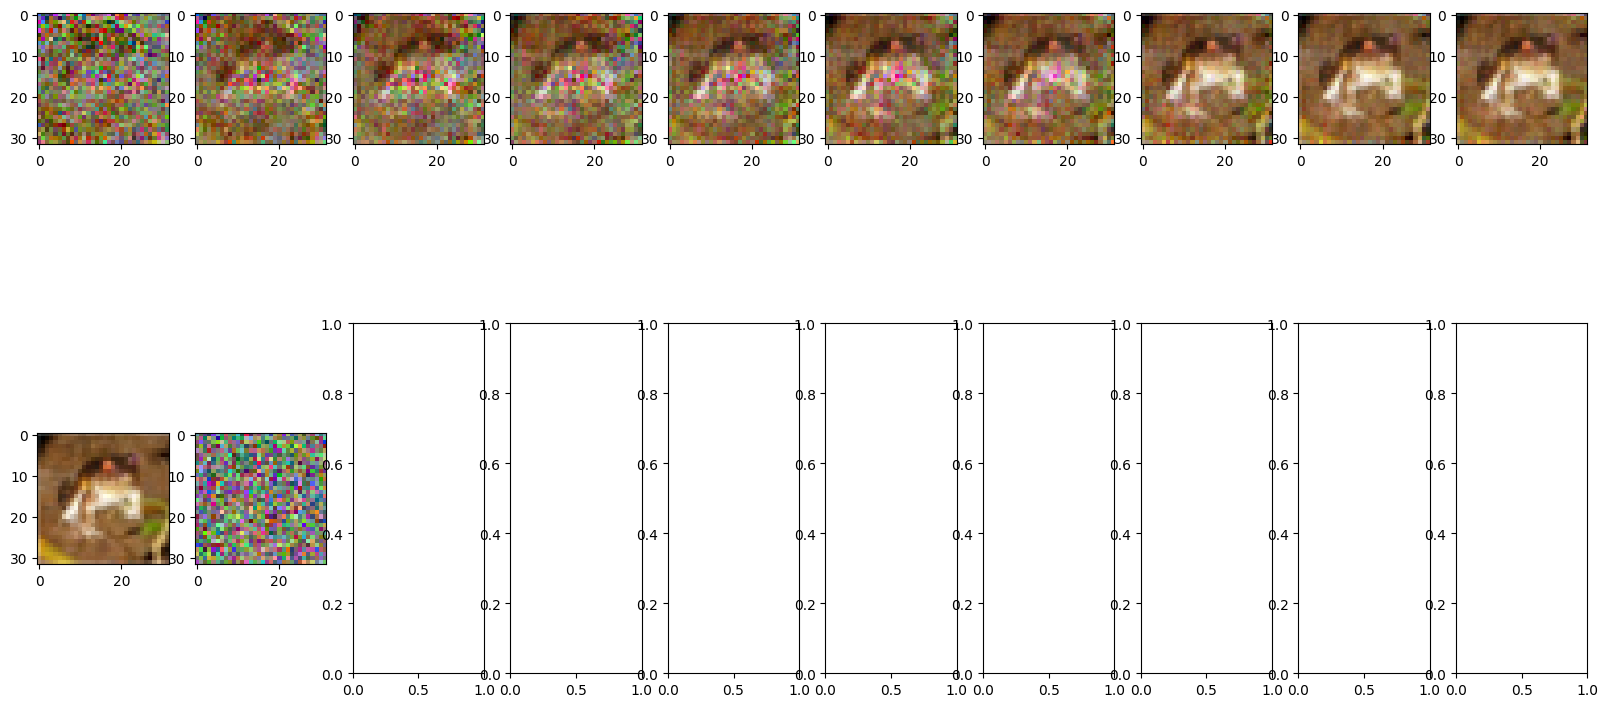

In [28]:
# Training setup
target_model = get_resnet18_32().to(device)
target_model.eval()

MAX_ITERS = 500
PRINT_STEP = 1000
LAMBDA_L2 = 1e-6
LAMBDA_TV = 1e-6
ATT_LR = 0.01

target_idx = 0
skips = [0]#[0, 1, 2, 3, 8]

test_dl = DataLoader(ds_test, batch_size=sample_batch_size, shuffle=False)
fig, axes = plt.subplots(len(skips)+1, 10, figsize=(20, 10))

sample_dl = DataLoader(ds_train, batch_size=attack_batch_size, shuffle=False)
for i, batch in enumerate(sample_dl):
    if i==target_idx:
        target_imgs, target_lbls = batch[0].to(device), batch[1].to(device)

        break

show_img(target_imgs[0].cpu().numpy(), axes[len(skips), 0])

target_imgs, target_lbls = target_imgs.to(device), target_lbls.to(device)

for j, skip in enumerate(skips):
    skip = j

    for img, lbl in test_dl:
        if lbl[0]==target_lbls[0]:
            if skip>0:
                skip-=1
                continue
            init_imgs = copy.deepcopy(img)
            break

    #init_imgs, _ = copy.deepcopy(next(iter(test_dl)))
    init_imgs = torch.randn(sample_batch_size, 3, 32, 32)
    #init_imgs =target_imgs

    
    
    imgs = copy.deepcopy(init_imgs)
    imgs=imgs.to(device)
    for i in range(10):
        #imgs = data_reconstruction_test(target_model, target_imgs, target_lbls, imgs, ATT_LR, MAX_ITERS, LAMBDA_L2, LAMBDA_TV, device=device, print_step=PRINT_STEP, loss_type="cosine")
        layers = [target_model.conv1]
        imgs = data_reconstruction_test(target_model, target_imgs, target_lbls, imgs,
                                        ATT_LR/(1**(i+1)), MAX_ITERS, LAMBDA_L2, LAMBDA_TV, device=device, print_step=PRINT_STEP, 
                                        loss_type="euclidean")
        show_img(imgs[0], axes[j, i])
        imgs = torch.tensor(imgs)

    show_img(init_imgs[0], axes[len(skips), 1+j])





# LFW

In [180]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms


DS_SLICE = 10000
IN_CH = 3
IN_W = 32
CLASSES = 10

DATASET_PATH = "/kaggle/input/lfw-dataset/lfw-deepfunneled"

transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

lfw_ds = datasets.ImageFolder(
    root=DATASET_PATH,
    transform=transform
)

ds_test_size = 0.2
ds_train = Subset(lfw_ds, indices=np.arange(int(DS_SLICE*(1-ds_test_size))))
ds_test = Subset(lfw_ds, indices=np.arange(int(DS_SLICE*(1-ds_test_size)), DS_SLICE))


In [187]:
model = torchvision.models.mobilenet_v2(weights=None)
model.features[0][0].stride = (1, 1)   # remove initial downsampling
model.classifier[1] = nn.Linear(model.last_channel, 10)
lfw_mobilenetv2 = model.to(device)

#train(lfw_mobilenetv2, ds_train, ds_test, 3)

/tmp/ipykernel_133/423216887.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  img = torch.tensor(img)


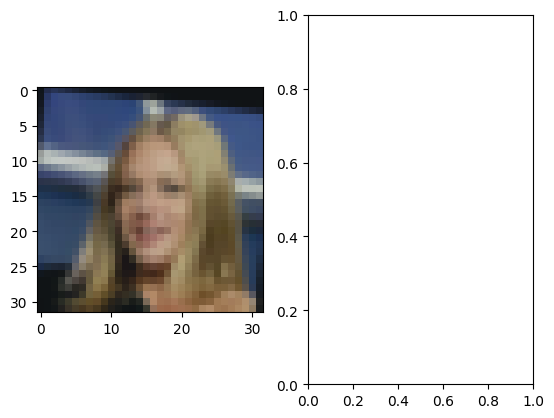

In [181]:
sample_batch_size = 1
attack_batch_size = 1#len(ds_train)
sample_dl = DataLoader(ds_train, batch_size=attack_batch_size, shuffle=False)
target_imgs, target_lbls = next(iter(sample_dl))

_, axes = plt.subplots(1, np.max([2, sample_batch_size]))

for i in range(sample_batch_size):
    show_img(target_imgs[i], axes[i])

/tmp/ipykernel_133/423216887.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  img = torch.tensor(img)


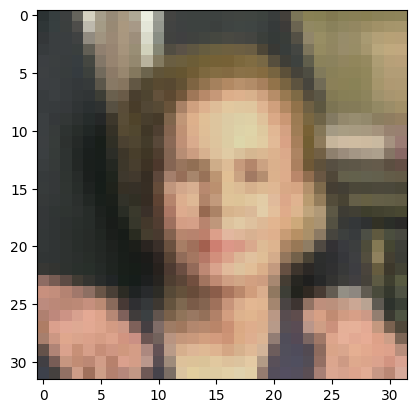

In [182]:
test_dl = DataLoader(ds_test, batch_size=attack_batch_size, shuffle=False)
init_imgs, _ = copy.deepcopy(next(iter(test_dl)))
show_img(init_imgs[0], plt.subplot())

Ended epoch 100/300
Ended epoch 200/300
Ended epoch 300/300


/tmp/ipykernel_133/423216887.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  img = torch.tensor(img)


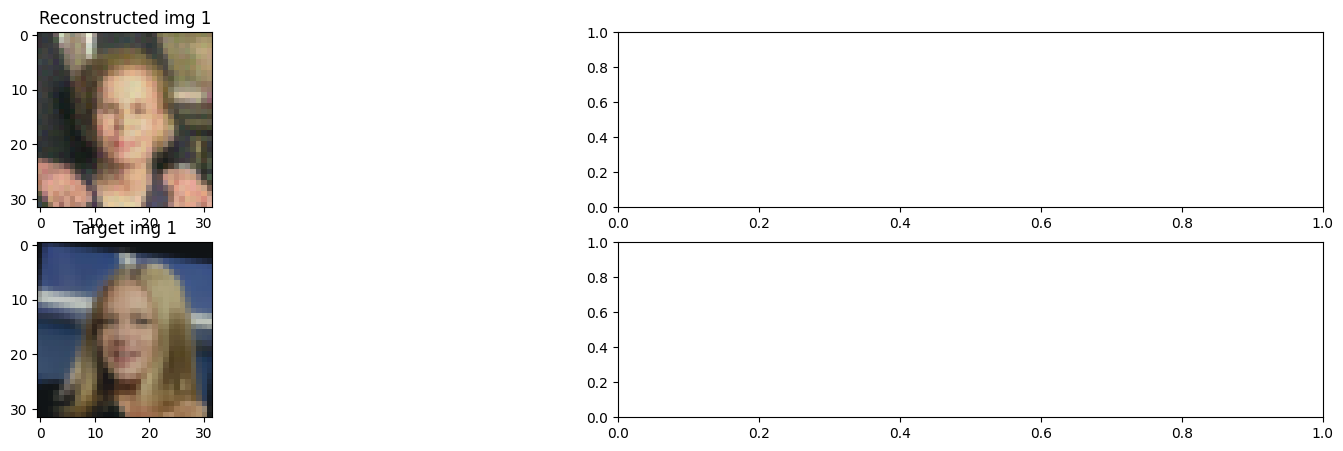

In [195]:
target_model = lfw_mobilenetv2

MAX_ITERS = 300
PRINT_STEP = 100
LAMBDA_L2 = 0#1e-3
LAMBDA_TV = 0#1e-4
ATT_LR = 0.01



test_dl = DataLoader(ds_test, batch_size=attack_batch_size, shuffle=False)
init_imgs, _ = copy.deepcopy(next(iter(test_dl)))
#init_imgs = torch.randn(sample_batch_size, 3, 32, 32)


imgs = data_reconstruction_test(target_model, target_imgs, target_lbls, init_imgs, ATT_LR, MAX_ITERS, LAMBDA_L2, LAMBDA_TV, device=device, print_step=PRINT_STEP, loss_type="euclidean")

#fig, axes = plt.subplots(2, sample_batch_size, figsize=(20, 5))
fig, axes = plt.subplots(2, np.max([2, sample_batch_size]), figsize=(20, 5))

for i in range(sample_batch_size):
    axes[0, i].set_title(f"Reconstructed img {i+1}")
    show_img(imgs[i], axes[0, i])

    axes[1, i].set_title(f"Target img {i+1}")
    show_img(target_imgs[i], axes[1, i])


Ended epoch 100/300
Ended epoch 200/300
Ended epoch 300/300


/tmp/ipykernel_133/423216887.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  img = torch.tensor(img)


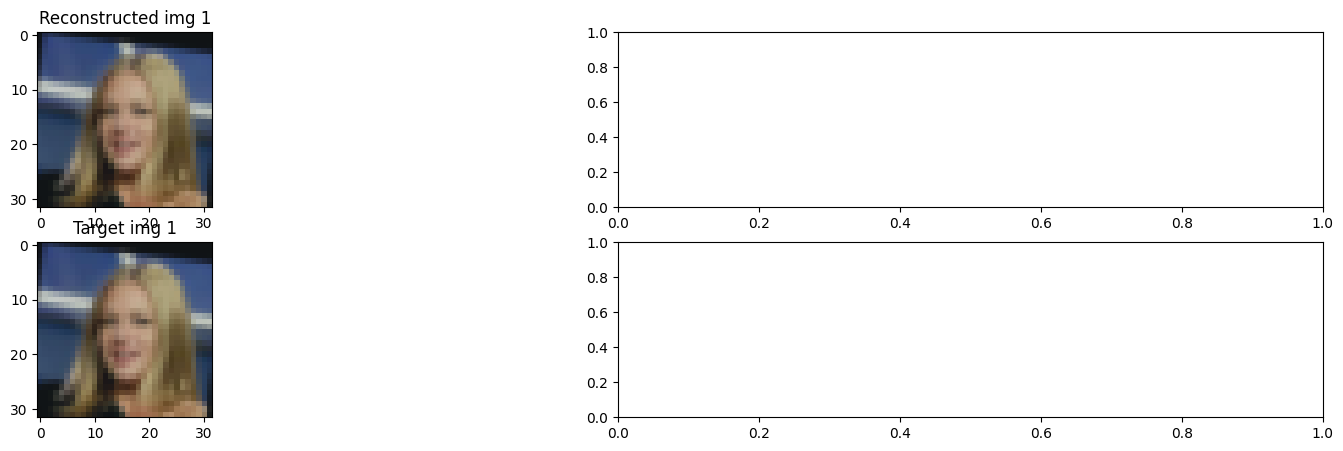

In [197]:
# Model
class MLP2(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3 * 32 * 32, 10000),
            nn.ReLU(),
            nn.Linear(10000, 5000),
            nn.ReLU(),
            nn.Linear(5000, 10)
        )

    def forward(self, x):
        return self.net(x)
    
# Training setup
lfw_mlp_model = MLP2().to(device)

target_model = lfw_mlp_model

MAX_ITERS = 300
PRINT_STEP = 100
LAMBDA_L2 = 0#1e-3
LAMBDA_TV = 0#1e-4
ATT_LR = 0.05



test_dl = DataLoader(ds_test, batch_size=attack_batch_size, shuffle=False)
init_imgs, _ = copy.deepcopy(next(iter(test_dl)))
#init_imgs = torch.randn(sample_batch_size, 3, 32, 32)


imgs = data_reconstruction_test(target_model, target_imgs, target_lbls, init_imgs, ATT_LR, MAX_ITERS, LAMBDA_L2, LAMBDA_TV, device=device, print_step=PRINT_STEP, loss_type="euclidean")

#fig, axes = plt.subplots(2, sample_batch_size, figsize=(20, 5))
fig, axes = plt.subplots(2, np.max([2, sample_batch_size]), figsize=(20, 5))

for i in range(sample_batch_size):
    axes[0, i].set_title(f"Reconstructed img {i+1}")
    show_img(imgs[i], axes[0, i])

    axes[1, i].set_title(f"Target img {i+1}")
    show_img(target_imgs[i], axes[1, i])